# Módulo 3 — Modelo de Clasificación
## Predicción de embarques en riesgo de retraso

---

### Objetivo de negocio
Construir un modelo que **prediga qué embarques tienen alto riesgo de NO llegar a tiempo**,
usando características conocidas al momento de planear el envío. El propósito es permitir
**intervención proactiva**: si sabemos de antemano que un embarque probablemente se
retrasará, podemos tomar medidas (cambiar carrier, priorizar, avisar al cliente) antes
de que el problema ocurra.

### Pregunta que responde
> *"Dado un embarque que está por salir, ¿qué probabilidad tiene de llegar tarde, y qué
> factores elevan ese riesgo?"*

### Diferencia con los módulos anteriores
- Módulo 1 (series de tiempo): predice un **valor futuro agregado** (gasto mensual).
- Módulo 2 (regresión): predice un **número continuo** (costo en dólares).
- Módulo 3 (clasificación): predice una **categoría** → ¿llega a tiempo (0) o tarde (1)?

### Datos utilizados
- **Fuente:** `02_shipments_limpio.csv` (219,120 embarques)
- **Variable objetivo:** `on_time_delivery_flag` (1 = a tiempo, 0 = tarde)
  - Nota: la reformularemos como "riesgo de retraso" para que 1 = tarde (el evento de interés).

### Metodología
Se entrenará un **Random Forest Classifier**, comparándolo con un baseline simple.
La clasificación requiere métricas distintas a la regresión, enfocadas en cuántos
retrasos detectamos correctamente y cuántas falsas alarmas generamos.

### Métricas de evaluación (para clasificación)
- **Accuracy:** % de predicciones correctas en total (puede engañar si hay desbalance).
- **Precision:** de los que predije como "tarde", ¿cuántos realmente lo fueron?
- **Recall:** de todos los que realmente llegaron tarde, ¿cuántos detecté?
- **F1-score:** balance entre precision y recall.
- **Matriz de confusión:** desglose visual de aciertos y errores.

---

## 1. Carga de datos y análisis del balance de clases

En un problema de clasificación, lo **primero** que debemos revisar es el **balance de
clases**: ¿cuántos embarques llegan a tiempo vs. cuántos llegan tarde?

**¿Por qué es tan importante?**
Si las clases están muy desbalanceadas (ej. 95% a tiempo, 5% tarde), un modelo "tramposo"
podría predecir "todos a tiempo" y acertar el 95% de las veces — pero sería **inútil**,
porque nunca detectaría un retraso. Por eso, conocer el balance define qué métricas usar
y si necesitamos técnicas especiales.

También reformulamos la variable objetivo: el dataset tiene `on_time_delivery_flag`
(1 = a tiempo), pero nos interesa predecir el **retraso**. Por claridad de negocio,
creamos `riesgo_retraso` donde **1 = llegó tarde** (el evento que queremos detectar).

✓ Datos cargados: 219,120 embarques

BALANCE DE CLASES
A tiempo (0):  183,893 embarques  (83.9%)
Tarde    (1):   35,227 embarques  (16.1%)


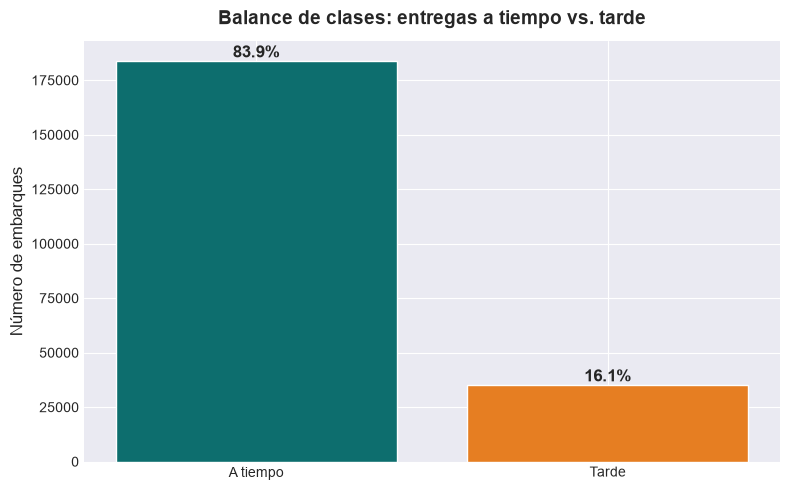

In [1]:
# ============================================================
# MÓDULO 3: CLASIFICACIÓN — Riesgo de retraso en embarques
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('deep')

# Cargar datos
df = pd.read_csv('../data/processed/02_shipments_limpio.csv')
print(f"✓ Datos cargados: {df.shape[0]:,} embarques")

# ---- Reformular la variable objetivo ----
# Original: on_time_delivery_flag (1 = a tiempo, 0 = tarde)
# Nueva: riesgo_retraso (1 = tarde, 0 = a tiempo) — el retraso es el evento de interés
df['riesgo_retraso'] = 1 - df['on_time_delivery_flag']

# ---- Analizar el balance de clases ----
conteo = df['riesgo_retraso'].value_counts().sort_index()
pct = df['riesgo_retraso'].value_counts(normalize=True).sort_index() * 100

print("\n" + "=" * 45)
print("BALANCE DE CLASES")
print("=" * 45)
print(f"A tiempo (0): {conteo[0]:>8,} embarques  ({pct[0]:.1f}%)")
print(f"Tarde    (1): {conteo[1]:>8,} embarques  ({pct[1]:.1f}%)")

# Gráfica del balance
fig, ax = plt.subplots(figsize=(8, 5))
colores = ['#0D6E6E', '#E67E22']
barras = ax.bar(['A tiempo', 'Tarde'], conteo.values, color=colores, edgecolor='white')
ax.set_ylabel('Número de embarques', fontsize=12)
ax.set_title('Balance de clases: entregas a tiempo vs. tarde',
             fontsize=14, fontweight='bold', pad=12)

# Agregar etiquetas de porcentaje sobre las barras
for barra, p in zip(barras, pct.values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
            f'{p:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretación del balance de clases

Las clases están **moderadamente desbalanceadas**:
- **A tiempo (83.9%):** 183,893 embarques
- **Tarde (16.1%):** 35,227 embarques

**Implicaciones para el modelado:**

1. **La accuracy por sí sola engaña.** Un modelo que prediga "todos a tiempo" lograría
   83.9% de accuracy sin detectar un solo retraso. Por eso priorizaremos **recall** y
   **F1-score** sobre accuracy: nos importa detectar los retrasos, no solo acertar el total.

2. **Usaremos `class_weight='balanced'`.** Este parámetro del Random Forest le indica al
   modelo que "preste más atención" a la clase minoritaria (los retrasos), compensando
   el desbalance sin necesidad de crear datos artificiales. Es una solución limpia y
   estándar para desbalances moderados como este.

3. **El foco de negocio es el recall de la clase "tarde".** En logística, es más costoso
   NO detectar un retraso (cliente molesto, penalizaciones) que dar una falsa alarma
   (revisar un embarque que en realidad iba bien). Por eso queremos capturar la mayor
   cantidad posible de retrasos reales.

## 2. Selección de variables y preparación

Igual que en el módulo de regresión, debemos evitar el **data leakage**: solo podemos
usar variables que se conocen **al momento de planear el embarque**, antes de saber si
llegó tarde o no.

**Variables que DEBEMOS EXCLUIR (leakage):**
- `on_time_delivery_flag` y `riesgo_retraso`: son el target, obviamente.
- `actual_transit_days`, `delivery_date`, `actual_delivery`: se conocen solo DESPUÉS de
  que el embarque llegó. Usarlas sería hacer trampa (predeciríamos el retraso con
  información del retraso mismo).
- Costos finales (`total_cost_usd`, etc.): se calculan al facturar, no antes.

**Variables que SÍ usaremos (conocidas al planear):**
- Físicas: `weight_kg`, `volume_cbm`, `chargeable_weight_kg`, `pallets`, `distance_km`
- Operativas: `mode`, `service_level`, `carrier_id`, `cross_border_flag`,
  `business_unit`, `customer_segment`, `incoterm`
- Planeadas: `planned_transit_days` (los días de tránsito prometidos/estimados)

La variable `planned_transit_days` es especialmente valiosa: representa el compromiso
de entrega, y las desviaciones respecto a él son la esencia del retraso.

In [2]:
# ============================================================
# Selección de variables (evitando data leakage)
# ============================================================

# Primero, verifiquemos qué columnas relacionadas con tránsito existen
# para no incluir accidentalmente alguna que cause leakage
cols_transito = [c for c in df.columns if 'transit' in c.lower()
                 or 'delivery' in c.lower() or 'actual' in c.lower()]
print("Columnas relacionadas con tránsito/entrega (revisar para evitar leakage):")
for c in cols_transito:
    print(f"  - {c}")
print()

# Variables numéricas predictoras (conocidas al planear el embarque)
features_num = ['weight_kg', 'volume_cbm', 'chargeable_weight_kg',
                'pallets', 'distance_km', 'planned_transit_days']

# Variables categóricas predictoras
features_cat = ['mode', 'service_level', 'carrier_id', 'cross_border_flag',
                'business_unit', 'customer_segment', 'incoterm']

# Variable objetivo
target = 'riesgo_retraso'

# Armar conjunto de trabajo
X = df[features_num + features_cat].copy()
y = df[target].copy()

print(f"✓ Variables predictoras: {len(features_num)} numéricas + {len(features_cat)} categóricas")
print(f"✓ Variable objetivo: {target} (1 = tarde, 0 = a tiempo)")
print(f"✓ Forma de X: {X.shape}")

Columnas relacionadas con tránsito/entrega (revisar para evitar leakage):
  - planned_transit_days
  - actual_transit_days
  - actual_pickup_ts
  - planned_delivery_ts
  - actual_delivery_ts
  - on_time_delivery_flag

✓ Variables predictoras: 6 numéricas + 7 categóricas
✓ Variable objetivo: riesgo_retraso (1 = tarde, 0 = a tiempo)
✓ Forma de X: (219120, 13)


## 3. División train/test estratificada

Dividimos en entrenamiento (80%) y prueba (20%), pero esta vez con una diferencia clave:
usamos **estratificación** (`stratify=y`).

**¿Qué es la estratificación y por qué importa aquí?**
Como las clases están desbalanceadas (83.9% / 16.1%), queremos asegurar que **esa misma
proporción se mantenga** tanto en el conjunto de entrenamiento como en el de prueba. Sin
estratificar, por azar podríamos terminar con muy pocos retrasos en el set de prueba, lo
que daría una evaluación poco confiable.

La estratificación garantiza que ambos conjuntos sean representativos del problema real.

In [3]:
# ============================================================
# División train/test estratificada + preprocesamiento
# ============================================================

# Split estratificado: mantiene la proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # clave: preserva el balance 83.9/16.1 en ambos conjuntos
)

print(f"✓ Entrenamiento: {X_train.shape[0]:,} embarques")
print(f"   - A tiempo: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"   - Tarde:    {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"✓ Prueba:        {X_test.shape[0]:,} embarques")
print(f"   - A tiempo: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"   - Tarde:    {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")

# Preprocesamiento: numéricas sin cambio, categóricas con One-Hot
preprocesador = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ]
)

print("\n✓ Preprocesador configurado (One-Hot para categóricas)")

✓ Entrenamiento: 175,296 embarques
   - A tiempo: 147,114 (83.9%)
   - Tarde:    28,182 (16.1%)
✓ Prueba:        43,824 embarques
   - A tiempo: 36,779 (83.9%)
   - Tarde:    7,045 (16.1%)

✓ Preprocesador configurado (One-Hot para categóricas)


## 4. Entrenamiento del Random Forest Classifier

Entrenamos un **Random Forest Classifier** para predecir el riesgo de retraso.
Usamos la misma familia de modelo que funcionó tan bien en el módulo de regresión, pero
en su versión de clasificación.

**Parámetros clave:**
- `n_estimators=100`: número de árboles.
- `max_depth=20`: profundidad máxima (previene sobreajuste).
- `class_weight='balanced'`: **crucial para el desbalance**. Le indica al modelo que dé
  más peso a la clase minoritaria (retrasos), penalizando más los errores sobre ella.
  Así el modelo no ignora los retrasos por ser menos frecuentes.
- `n_jobs=-1`: usa todos los núcleos del procesador.
- `random_state=42`: reproducibilidad.

Recordemos que, por el desbalance, evaluaremos con **precision, recall y F1** enfocados
en la clase "tarde", no solo con accuracy.

### ¿Por qué Random Forest y no otro clasificador?

Existen muchos algoritmos de clasificación. Elegimos Random Forest tras considerar
las alternativas principales:

| Modelo | Ventajas | Por qué NO fue la primera opción aquí |
|--------|----------|----------------------------------------|
| **Regresión Logística** | Simple, interpretable, rápida. | Asume relaciones lineales; nuestro problema tiene interacciones complejas (ej. carrier + modo + distancia) que no captura bien. Sí serviría como *baseline*. |
| **Random Forest** ✅ | Maneja no linealidad, interacciones y variables mixtas; robusto; da importancia de variables; poco ajuste requerido. | **Elegido:** mejor balance entre desempeño, robustez e interpretabilidad para este caso. |
| **XGBoost / LightGBM** | Suele dar el mejor desempeño puro; muy usado en competencias. | Requiere más ajuste de hiperparámetros para evitar sobreajuste. Es un excelente *siguiente paso* si necesitáramos exprimir más desempeño. |
| **SVM (máquinas de soporte)** | Potente en espacios de alta dimensión. | Escala mal con 219,000 filas (muy lento). Poco práctico a este volumen. |
| **K-Nearest Neighbors** | Intuitivo, sin entrenamiento. | Lento en predicción con tantos datos; sensible a la escala y a variables irrelevantes. |

**Decisión:** Random Forest ofrece el mejor equilibrio entre **desempeño, robustez ante
el desbalance** (`class_weight`), **interpretabilidad** (importancia de variables) y
**bajo esfuerzo de ajuste**. XGBoost queda documentado como la vía de mejora futura si
se buscara maximizar el desempeño.

In [4]:
# ============================================================
# Entrenar Random Forest Classifier
# ============================================================

modelo_clf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clasificador', RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced',   # compensa el desbalance de clases
        n_jobs=-1,
        random_state=42
    ))
])

# Entrenar (puede tardar 1-3 minutos, como en el módulo anterior)
print("Entrenando Random Forest Classifier... (puede tardar unos minutos)")
modelo_clf.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba
pred_clf = modelo_clf.predict(X_test)

# También obtenemos las probabilidades (útil para la curva ROC después)
proba_clf = modelo_clf.predict_proba(X_test)[:, 1]  # probabilidad de "tarde"

print("✓ Modelo entrenado y evaluado")
print(f"✓ Predicciones generadas para {len(pred_clf):,} embarques de prueba")

Entrenando Random Forest Classifier... (puede tardar unos minutos)
✓ Modelo entrenado y evaluado
✓ Predicciones generadas para 43,824 embarques de prueba


## 5. Evaluación del modelo

Evaluamos el desempeño con las métricas apropiadas para clasificación desbalanceada.
Recordemos qué significa cada una en nuestro contexto:

- **Precision (de la clase "tarde"):** de todos los embarques que el modelo marcó como
  "riesgo de retraso", ¿qué % realmente se retrasó? Alta precision = pocas falsas alarmas.
- **Recall (de la clase "tarde"):** de todos los embarques que realmente se retrasaron,
  ¿qué % logró detectar el modelo? Alto recall = pocos retrasos se le escapan.
- **F1-score:** media armónica entre precision y recall (balance entre ambas).

En logística, el **recall de la clase "tarde" suele ser lo más importante**: preferimos
detectar la mayoría de los retrasos (aunque genere algunas falsas alarmas) que dejar
pasar retrasos sin avisar.

In [5]:
# ============================================================
# Reporte de clasificación completo
# ============================================================

print("=" * 55)
print("REPORTE DE CLASIFICACIÓN — Riesgo de retraso")
print("=" * 55)
print()
print(classification_report(
    y_test, pred_clf,
    target_names=['A tiempo (0)', 'Tarde (1)'],
    digits=3
))

# AUC-ROC: métrica global de capacidad discriminativa
auc = roc_auc_score(y_test, proba_clf)
print("=" * 55)
print(f"AUC-ROC: {auc:.4f}")
print("=" * 55)
print()
print("Interpretación del AUC:")
print("  0.5 = modelo aleatorio (inútil)")
print("  0.7-0.8 = aceptable")
print("  0.8-0.9 = bueno")
print("  >0.9 = excelente")

REPORTE DE CLASIFICACIÓN — Riesgo de retraso

              precision    recall  f1-score   support

A tiempo (0)      0.866     0.792     0.828     36779
   Tarde (1)      0.250     0.363     0.296      7045

    accuracy                          0.723     43824
   macro avg      0.558     0.577     0.562     43824
weighted avg      0.767     0.723     0.742     43824

AUC-ROC: 0.6269

Interpretación del AUC:
  0.5 = modelo aleatorio (inútil)
  0.7-0.8 = aceptable
  0.8-0.9 = bueno
  >0.9 = excelente


### Interpretación: un modelo débil (y por qué eso es un hallazgo)

Los resultados muestran un **desempeño limitado**, y es importante reportarlo con honestidad:

| Métrica (clase "Tarde") | Valor | Lectura |
|--------------------------|-------|---------|
| Precision | 0.250 | De cada 4 embarques marcados como "riesgo", solo 1 se retrasa realmente (muchas falsas alarmas). |
| Recall | 0.363 | El modelo detecta solo ~36% de los retrasos reales (se le escapan 2 de cada 3). |
| F1-score | 0.296 | Bajo, reflejo del pobre balance precision/recall. |
| AUC-ROC | 0.627 | Apenas superior al azar (0.5); capacidad discriminativa débil. |

**¿Por qué el modelo no funciona bien? (hallazgo de negocio)**

El desempeño limitado **no es un error de implementación**, sino una señal reveladora:
las variables disponibles (peso, distancia, modo, carrier, servicio) **no contienen
suficiente información para predecir los retrasos**. Esto sugiere que los retrasos
dependen de factores **no capturados en el dataset**, como:
- Condiciones climáticas
- Congestión en aduanas o puertos
- Problemas operativos puntuales (disponibilidad de unidades, personal)
- Eventos externos (feriados, huelgas, tráfico)

**Nota sobre el trade-off:** al usar `class_weight='balanced'`, el modelo sacrifica
accuracy (bajó de 83.9% a 72.3%) para intentar detectar más retrasos. Aun así, el recall
sigue siendo bajo, confirmando que el problema no es de ajuste sino de **falta de señal
predictiva en las variables**.

**Conclusión honesta:** reportamos este resultado tal cual. Un buen análisis no oculta
los modelos que no funcionan; los interpreta. Aquí, el "fracaso" del modelo es en sí mismo
un hallazgo: *para predecir retrasos, la empresa necesitaría capturar datos adicionales.*

## 6. Visualización del desempeño

Dos gráficas estándar para evaluar un clasificador:

1. **Matriz de confusión:** desglosa los aciertos y errores en cuatro celdas —
   verdaderos positivos/negativos y falsos positivos/negativos. Permite ver exactamente
   dónde se equivoca el modelo.

2. **Curva ROC:** muestra la capacidad del modelo para distinguir entre clases a
   distintos umbrales. Cuanto más se acerque la curva a la esquina superior izquierda,
   mejor. La diagonal representa el azar (AUC = 0.5).

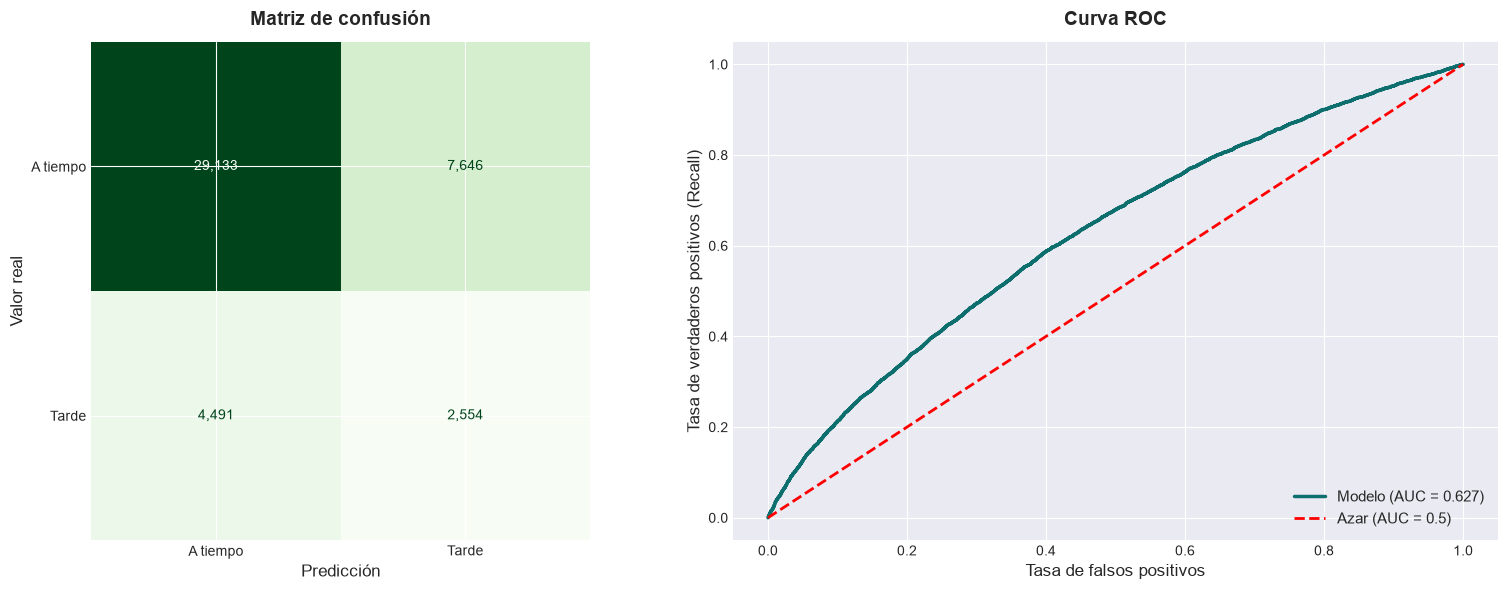

Desglose de la matriz de confusión:
  Verdaderos negativos (a tiempo, bien predichos): 29,133
  Falsos positivos (falsas alarmas de retraso):    7,646
  Falsos negativos (retrasos NO detectados):       4,491
  Verdaderos positivos (retrasos bien detectados): 2,554


In [6]:
# ============================================================
# Visualizaciones del desempeño del clasificador
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Gráfica 1: Matriz de confusión ----
cm = confusion_matrix(y_test, pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['A tiempo', 'Tarde'])
disp.plot(ax=axes[0], cmap='Greens', colorbar=False, values_format=',d')
axes[0].set_title('Matriz de confusión', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicción', fontsize=12)
axes[0].set_ylabel('Valor real', fontsize=12)

# ---- Gráfica 2: Curva ROC ----
fpr, tpr, _ = roc_curve(y_test, proba_clf)
axes[1].plot(fpr, tpr, color='#0D6E6E', linewidth=2.5,
             label=f'Modelo (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Azar (AUC = 0.5)')
axes[1].set_xlabel('Tasa de falsos positivos', fontsize=12)
axes[1].set_ylabel('Tasa de verdaderos positivos (Recall)', fontsize=12)
axes[1].set_title('Curva ROC', fontsize=14, fontweight='bold', pad=12)
axes[1].legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

# Desglose de la matriz de confusión en palabras
tn, fp, fn, tp = cm.ravel()
print("Desglose de la matriz de confusión:")
print(f"  Verdaderos negativos (a tiempo, bien predichos): {tn:,}")
print(f"  Falsos positivos (falsas alarmas de retraso):    {fp:,}")
print(f"  Falsos negativos (retrasos NO detectados):       {fn:,}")
print(f"  Verdaderos positivos (retrasos bien detectados): {tp:,}")

### Interpretación de las gráficas

**Matriz de confusión:**
El desglose confirma la debilidad del modelo en la clase de interés:
- **2,554 retrasos detectados correctamente**, pero **4,491 retrasos se escaparon**
  (falsos negativos). El modelo deja pasar más retrasos de los que detecta.
- **7,646 falsas alarmas** (falsos positivos): embarques marcados como riesgo que
  en realidad llegaron a tiempo.

Esto ilustra el doble problema: bajo recall (se escapan retrasos) y baja precision
(muchas falsas alarmas).

**Curva ROC:**
La curva del modelo se sitúa levemente por encima de la diagonal del azar, pero sin
acercarse a la esquina superior izquierda (el ideal). El **AUC de 0.627** confirma
visualmente que la capacidad discriminativa es débil: el modelo distingue entre "a
tiempo" y "tarde" solo marginalmente mejor que una predicción aleatoria.

**Conclusión visual:** ambas gráficas refuerzan el diagnóstico —las variables disponibles
no bastan para predecir retrasos de forma confiable.

## 7. Comparación de modelos: ¿el problema es el modelo o los datos?

El Random Forest dio un desempeño débil (AUC = 0.627). Antes de concluir, debemos
responder una pregunta clave con rigor:

> **¿El bajo desempeño se debe al modelo elegido, o a que los datos no contienen
> suficiente señal predictiva?**

Para responderlo empíricamente, entrenamos y comparamos **tres modelos** de distinta
naturaleza:
1. **Regresión Logística:** modelo lineal simple (baseline).
2. **Random Forest:** ensamble de árboles (el que ya probamos).
3. **XGBoost:** *gradient boosting*, considerado uno de los algoritmos más potentes
   para datos tabulares.

**La lógica del experimento:** si XGBoost —el modelo más potente— tampoco logra mejorar
significativamente, tendremos **evidencia sólida** de que el límite está en los **datos**,
no en el modelo. Si en cambio XGBoost mejora mucho, significaría que Random Forest no era
el adecuado.

Todos usan las mismas variables y el mismo split para una comparación justa.

In [8]:
# ============================================================
# Entrenar y comparar tres modelos
# ============================================================

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Diccionario de modelos a comparar
modelos = {
    'Regresión Logística': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=20, class_weight='balanced',
        n_jobs=-1, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),  # compensa desbalance
        n_jobs=-1, random_state=42, eval_metric='logloss'
    )
}

# Entrenar cada uno y guardar resultados
resultados = []

for nombre, clf in modelos.items():
    print(f"Entrenando {nombre}...")

    # Pipeline con el mismo preprocesamiento
    pipe = Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('clasificador', clf)
    ])
    pipe.fit(X_train, y_train)

    # Predecir
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    # Métricas
    from sklearn.metrics import precision_score, recall_score, f1_score
    resultados.append({
        'Modelo': nombre,
        'AUC-ROC': roc_auc_score(y_test, proba),
        'Precision (tarde)': precision_score(y_test, pred, pos_label=1),
        'Recall (tarde)': recall_score(y_test, pred, pos_label=1),
        'F1 (tarde)': f1_score(y_test, pred, pos_label=1)
    })

print("\n✓ Los tres modelos entrenados\n")

# Tabla comparativa
tabla = pd.DataFrame(resultados).round(4)
print("=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)
print(tabla.to_string(index=False))

Entrenando Regresión Logística...


E:\Analisis de Datos\Proyectos\transportation-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Entrenando Random Forest...
Entrenando XGBoost...

✓ Los tres modelos entrenados

COMPARACIÓN DE MODELOS
             Modelo  AUC-ROC  Precision (tarde)  Recall (tarde)  F1 (tarde)
Regresión Logística   0.6416             0.2357          0.5370      0.3276
      Random Forest   0.6269             0.2504          0.3625      0.2962
            XGBoost   0.6446             0.2336          0.5638      0.3303
